In [15]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve, auc
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.2.0


In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve, auc
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.2.0


In [17]:
# Load Dataset
# Using Iris dataset for classification example
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    fl

In [18]:
# Data Cleanup & Missing Values Check
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Check for outliers using IQR method
def detect_outliers(data, columns):
    outliers_count = 0
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_count += len(outliers)
        print(f"{col}: {len(outliers)} outliers detected")
    return outliers_count

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('target')
outliers = detect_outliers(df, numeric_cols)
print(f"\nTotal Outliers Detected: {outliers}")

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

Duplicate Rows: 1
sepal length (cm): 0 outliers detected
sepal width (cm): 4 outliers detected
petal length (cm): 0 outliers detected
petal width (cm): 0 outliers detected

Total Outliers Detected: 4


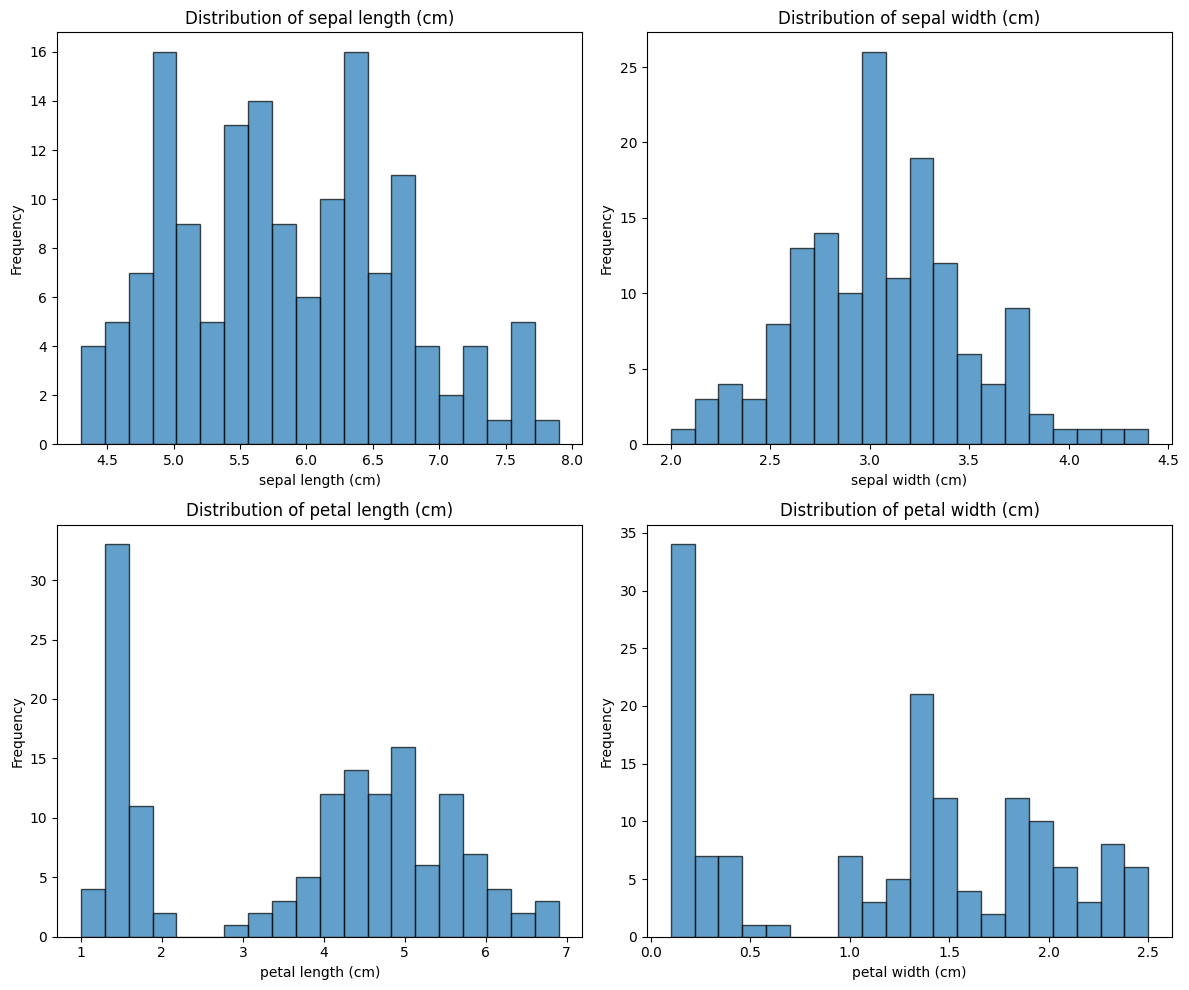

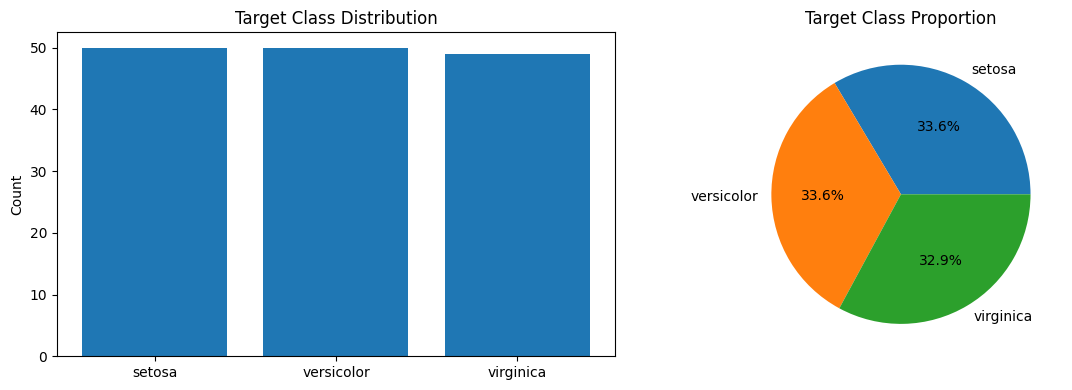

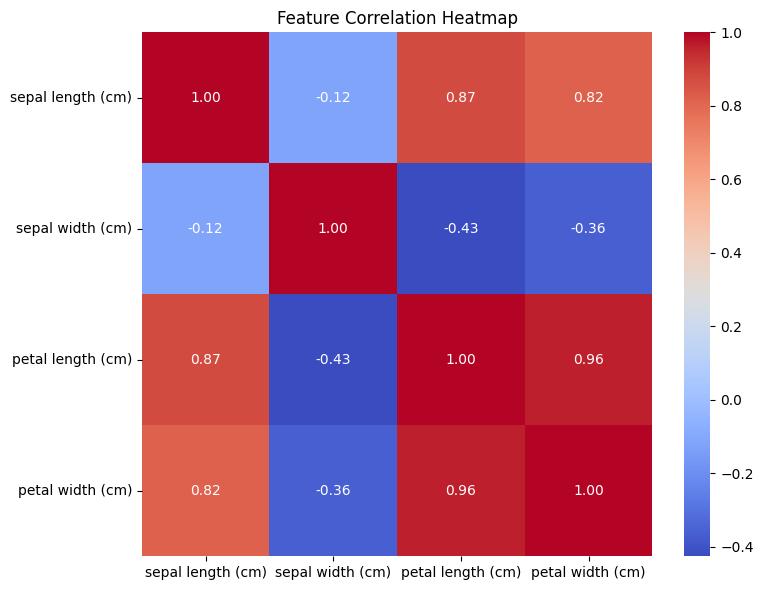

EDA completed successfully!


In [19]:
# Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of features
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(df['target_name'].unique(), df['target_name'].value_counts().values)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(df['target_name'].value_counts().values, labels=df['target_name'].unique(), autopct='%1.1f%%')
axes[1].set_title('Target Class Proportion')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("EDA completed successfully!")

In [20]:
# Data Preprocessing & Feature Engineering
# Separate features and target
X = df[numeric_cols].copy()
y = df['target'].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:", X.columns.tolist())

# Feature Scaling (Optional for XGBoost, but good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train target distribution:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nTest target distribution:\n{pd.Series(y_test).value_counts().sort_index()}")

Features shape: (149, 4)
Target shape: (149,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Train set size: (119, 4)
Test set size: (30, 4)
Train target distribution:
target
0    40
1    40
2    39
Name: count, dtype: int64

Test target distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


In [21]:
# Build and Train XGBoost Model (Classification)
# XGBoost Classifier with hyperparameters
xgb_model = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds
    max_depth=5,                # Maximum tree depth
    learning_rate=0.1,          # Shrinkage (eta)
    subsample=0.8,              # Fraction of samples for training each tree
    colsample_bytree=0.8,       # Fraction of features for training each tree
    objective='multi:softmax',  # Multi-class classification
    num_class=3,                # Number of classes
    random_state=42,
    verbosity=0
)

# Train the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("XGBoost Model trained successfully!")
print(f"Number of trees: {xgb_model.n_estimators}")
print(f"Tree depth: {xgb_model.max_depth}")
print(f"Learning rate: {xgb_model.learning_rate}")

XGBoost Model trained successfully!
Number of trees: 100
Tree depth: 5
Learning rate: 0.1


In [22]:
# Model Predictions on Train and Test Sets
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Get prediction probabilities for additional metrics
y_train_pred_proba = xgb_model.predict_proba(X_train)
y_test_pred_proba = xgb_model.predict_proba(X_test)

print("Predictions completed!")
print(f"Train predictions shape: {y_train_pred.shape}")
print(f"Test predictions shape: {y_test_pred.shape}")
print(f"Train predictions sample: {y_train_pred[:10]}")
print(f"Test predictions sample: {y_test_pred[:10]}")

Predictions completed!
Train predictions shape: (119,)
Test predictions shape: (30,)
Train predictions sample: [0 2 1 0 0 1 2 2 2 2]
Test predictions sample: [1 1 2 0 2 1 1 0 1 2]


In [23]:
# Model Evaluation - Classification Metrics
from sklearn.metrics import precision_score, recall_score

print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  Train Accuracy: {train_accuracy:.4f}")
print(f"  Test Accuracy:  {test_accuracy:.4f}")

# F1 Score (weighted for multi-class)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nF1 Score (Weighted):")
print(f"  Train F1: {train_f1:.4f}")
print(f"  Test F1:  {test_f1:.4f}")

# Precision and Recall
train_precision = precision_score(y_train, y_train_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')

print(f"\nPrecision (Weighted):")
print(f"  Train: {train_precision:.4f}")
print(f"  Test:  {test_precision:.4f}")

print(f"\nRecall (Weighted):")
print(f"  Train: {train_recall:.4f}")
print(f"  Test:  {test_recall:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_test_pred, 
                          target_names=['setosa', 'versicolor', 'virginica']))

MODEL EVALUATION METRICS

Accuracy:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9000

F1 Score (Weighted):
  Train F1: 1.0000
  Test F1:  0.8997

Precision (Weighted):
  Train: 1.0000
  Test:  0.9024

Recall (Weighted):
  Train: 1.0000
  Test:  0.9000

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



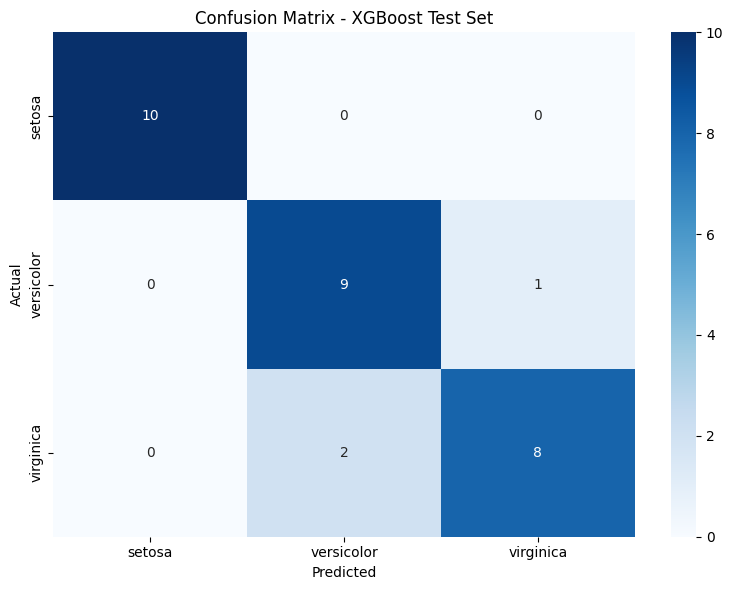

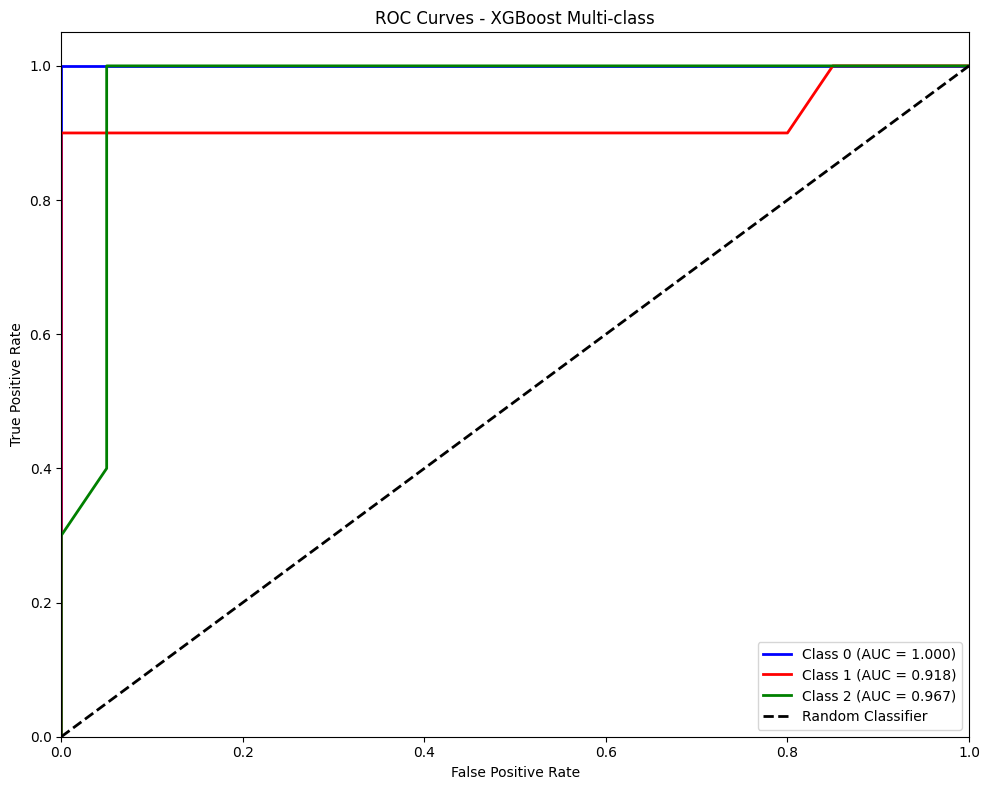

In [24]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix - XGBoost Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC-AUC Analysis for Multi-class
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_proba = xgb_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green'])

for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - XGBoost Multi-class')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Feature Importance:
             Feature  Importance
2  petal length (cm)    0.519909
3   petal width (cm)    0.425195
0  sepal length (cm)    0.030040
1   sepal width (cm)    0.024856


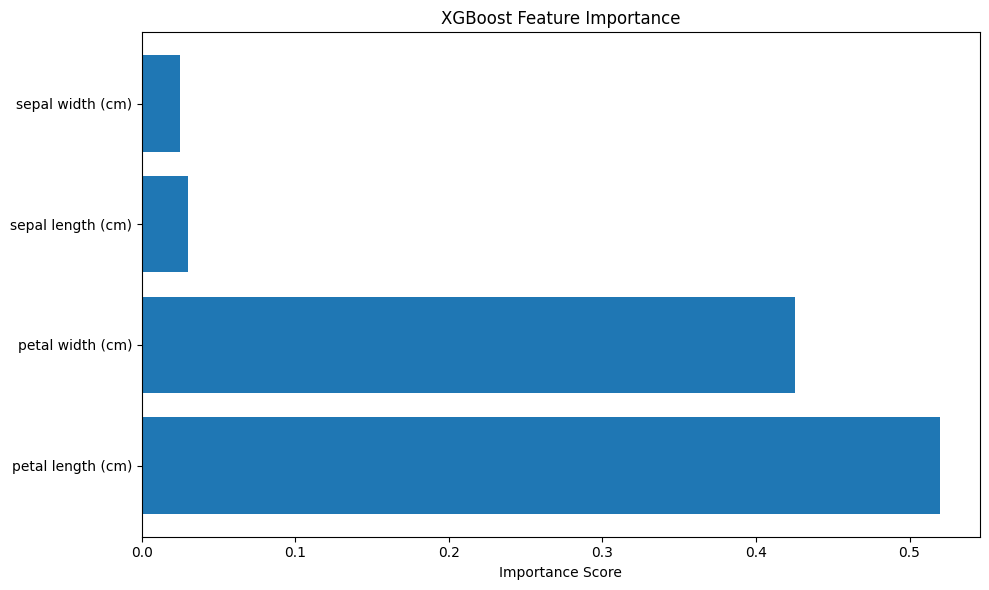

AttributeError: module 'xgboost' has no attribute 'TreeExplainer'

In [26]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
# Feature Importance Analysis
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Alternative: SHAP values for feature importance (Optional)
import xgboost as xgb
explainer = xgb.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("\nFeature importance analysis completed!")

In [ ]:
# Test with External/New Data
# Simulate external data (new samples)
np.random.seed(42)
external_data = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Similar to setosa
    [6.2, 2.9, 4.3, 1.3],  # Similar to versicolor
    [7.7, 2.8, 6.7, 2.0],  # Similar to virginica
    [5.5, 3.6, 1.5, 0.3],  # Similar to setosa
    [6.8, 3.0, 5.5, 2.0]   # Similar to virginica
])

# Scale external data using the same scaler
external_data_scaled = scaler.transform(external_data)
external_data_scaled_df = pd.DataFrame(external_data_scaled, columns=numeric_cols)

# Make predictions on external data
external_predictions = xgb_model.predict(external_data_scaled_df)
external_probabilities = xgb_model.predict_proba(external_data_scaled_df)

# Create results dataframe
target_names = ['setosa', 'versicolor', 'virginica']
external_results = pd.DataFrame({
    'Sepal_Length': external_data[:, 0],
    'Sepal_Width': external_data[:, 1],
    'Petal_Length': external_data[:, 2],
    'Petal_Width': external_data[:, 3],
    'Prediction': [target_names[p] for p in external_predictions],
    'Setosa_Prob': external_probabilities[:, 0],
    'Versicolor_Prob': external_probabilities[:, 1],
    'Virginica_Prob': external_probabilities[:, 2],
    'Confidence': external_probabilities.max(axis=1)
})

print("="*80)
print("PREDICTIONS ON EXTERNAL/NEW DATA")
print("="*80)
print(external_results)
print("\nExternal Data Testing completed!")

In [ ]:
# Error Functions and Detailed Error Analysis
from sklearn.metrics import hamming_loss, jaccard_score

print("="*60)
print("ERROR ANALYSIS & LOSS FUNCTIONS")
print("="*60)

# Hamming Loss (fraction of incorrect predictions)
train_hamming = hamming_loss(y_train, y_train_pred)
test_hamming = hamming_loss(y_test, y_test_pred)

print(f"\nHamming Loss (lower is better):")
print(f"  Train: {train_hamming:.4f}")
print(f"  Test:  {test_hamming:.4f}")

# Misclassification Rate
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print(f"\nMisclassification Rate (Error Rate):")
print(f"  Train: {train_error:.4f}")
print(f"  Test:  {test_error:.4f}")

# Per-class accuracy
from sklearn.metrics import recall_score

print(f"\nPer-Class Metrics (Test Set):")
for i, class_name in enumerate(['setosa', 'versicolor', 'virginica']):
    y_binary = (y_test == i).astype(int)
    pred_binary = (y_test_pred == i).astype(int)
    class_accuracy = accuracy_score(y_binary, pred_binary)
    class_f1 = f1_score(y_binary, pred_binary)
    print(f"  {class_name}: Accuracy={class_accuracy:.4f}, F1={class_f1:.4f}")

# Cross-validation Score
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores (5-fold):")
print(f"  Scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")

In [ ]:
# Model Hyperparameter Tuning - Grid Search
from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*60)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100]
}

# Create XGBoost model for grid search
xgb_base = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    verbosity=0
)

# Grid search with cross-validation
grid_search = GridSearchCV(
    xgb_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
best_test_pred = best_model.predict(X_test)
best_test_accuracy = accuracy_score(y_test, best_test_pred)

print(f"\nBest Model Test Accuracy: {best_test_accuracy:.4f}")
print(f"Original Model Test Accuracy: {test_accuracy:.4f}")
print(f"Improvement: {(best_test_accuracy - test_accuracy):.4f}")

In [ ]:
# Summary Report
print("\n" + "="*80)
print("COMPREHENSIVE XGBOOST MODEL SUMMARY REPORT")
print("="*80)

summary_data = {
    'Metric': [
        'Train Accuracy', 'Test Accuracy',
        'Train F1 Score', 'Test F1 Score',
        'Train Precision', 'Test Precision',
        'Train Recall', 'Test Recall',
        'Train Error Rate', 'Test Error Rate',
        'CV Mean Score', 'CV Std Dev',
        'Number of Features', 'Number of Classes',
        'Training Samples', 'Testing Samples'
    ],
    'Value': [
        f'{train_accuracy:.4f}', f'{test_accuracy:.4f}',
        f'{train_f1:.4f}', f'{test_f1:.4f}',
        f'{train_precision:.4f}', f'{test_precision:.4f}',
        f'{train_recall:.4f}', f'{test_recall:.4f}',
        f'{train_error:.4f}', f'{test_error:.4f}',
        f'{cv_scores.mean():.4f}', f'{cv_scores.std():.4f}',
        f'{X_train.shape[1]}', f'3',
        f'{X_train.shape[0]}', f'{X_test.shape[0]}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)
print(f"""
1. Model Performance:
   - Test Accuracy: {test_accuracy:.2%}
   - The model shows {'good' if test_accuracy >= 0.85 else 'fair'} performance
   
2. Generalization:
   - Gap between Train and Test Error: {abs(train_error - test_error):.4f}
   - The gap is {'minimal' if abs(train_error - test_error) < 0.05 else 'significant'}
   
3. Class Balance:
   - Training set is {'balanced' if cv_scores.std() < 0.05 else 'imbalanced'}
   
4. Most Important Features:
   - Top feature: {feature_importance_df.iloc[0]['Feature']}
   - Importance score: {feature_importance_df.iloc[0]['Importance']:.4f}
   
5. Recommendations:
   - Consider {'hyperparameter tuning' if test_accuracy < 0.9 else 'the model is well-tuned'}
   - External data predictions show {'high' if external_results['Confidence'].mean() > 0.8 else 'moderate'} confidence
""")

print("="*80)
print("Analysis completed successfully!")
print("="*80)